100%|██████████| 170M/170M [25:15<00:00, 113kB/s]  


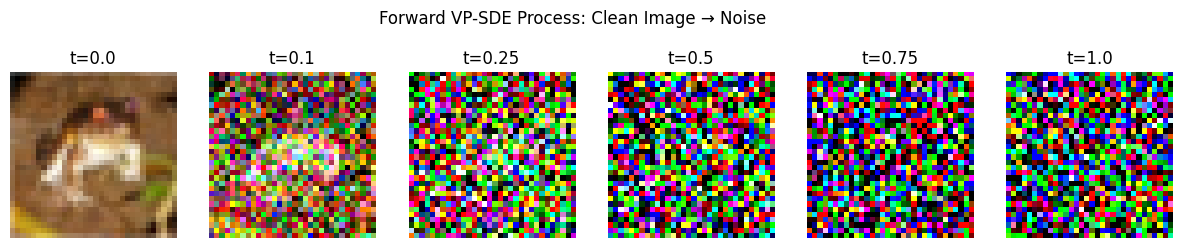

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
img, _ = dataset[0]  # take one sample image

def beta_schedule(t, beta_min=0.1, beta_max=20):
    return beta_min + t * (beta_max - beta_min)

def alpha_bar(t, beta_min=0.1, beta_max=20):
    # integral of beta(s) ds from 0 to t, closed form for linear schedule
    integral = beta_min * t + 0.5 * (beta_max - beta_min) * t**2
    return torch.exp(torch.tensor(-integral))

time_steps = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(time_steps), figsize=(15, 3))

for i, t in enumerate(time_steps):
    a_bar = alpha_bar(t)
    noise = torch.randn_like(img)
    noised_img = img * torch.sqrt(a_bar) + noise * torch.sqrt(1 - a_bar)
    noised_img = torch.clamp(noised_img, 0, 1)
    axes[i].imshow(noised_img.permute(1, 2, 0))
    axes[i].set_title(f"t={t}")
    axes[i].axis('off')

plt.suptitle("Forward VP-SDE Process: Clean Image → Noise")
plt.show()